# NASA AI/ML STIG: Convolutional Neural Networks

**Author:** John F. Wu

**Date:** January 26, 2026


## Introduction
In this tutorial, we will build a convolutional neural network (CNN) that can estimate the physical properties of a galaxy directly from its image. Specifically, we will predict the **gas-phase metallicity** ($Z$) of galaxies using images from the Sloan Digital Sky Survey (SDSS).

Traditionally, measuring metallicity requires spectroscopy, which is observationally expensive. Meanwhile, imaging is cheap and fast. If we can train a neural network to infer metallicity from galaxy color gradients and morphology in images, then we may be able to study millions of galaxies that haven't been spectroscopically observed.

This replicates the main finding from [Wu & Boada (2019)](https://ui.adsabs.harvard.edu/abs/2019MNRAS.484.4683W/abstract), albeit with a smaller data set for pedagogical purposes.

### Roadmap
1. Load galaxy images as tensors ($g,r,i$ bands)
2. Build a Convolutional Neural Network (CNN) model from scratch using PyTorch
3. Optimize the model using gradient descent
4. Evaluate how well our neural network performs


In [ ]:
# @title Import Pytorch and set device (GPU/CPU)
import os
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Set device to GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


We will use a curated dataset of ~14,000 galaxies cross-matched between SDSS imaging and spectroscopy.
* **Inputs:** JPG images ($g, r, i$ filters mapped to blue, green, red channels).
* **Targets:** Gas-phase metallicity ($12 + \log(\text{O/H})$).

Note that I've already selected a clean and small subsample from the entire SDSS Main Galaxy Survey, which is spectroscopically complete for galaxies in the SDSS footprint with $r < 17.78$ (modulo fiber collisions).

## Data

In [ ]:
# @title Download catalogs and images
if not os.path.exists('galaxies.csv'):
    print("Downloading catalog...")
    urllib.request.urlretrieve('https://www.dropbox.com/s/e5rfeg71ub8ab0k/galaxies.csv?dl=1', 'galaxies.csv')

if not os.path.exists('images.tar.gz'):
    print("Downloading images...")
    urllib.request.urlretrieve('https://www.dropbox.com/s/ru3cgknmidn0re9/images.tar.gz?dl=1', 'images.tar.gz')

    print("Extracting images...")
    with tarfile.open('images.tar.gz', 'r:gz') as tar:
        tar.extractall()

### Let's take a look at the catalogs...

In [ ]:
df = pd.read_csv('galaxies.csv', dtype={'objID': str})
print(f"Dataset contains {len(df)} galaxies.")

Dataset contains 14015 galaxies.


In [ ]:
df.head(3)

,objID,ra,dec,z,lgm_tot_p50,sfr_tot_p50,oh_p50
0,1237660958105272676,118.570999,22.084926,0.047724,9.887146,-0.029765,8.825988
1,1237662264863818136,238.343336,6.911807,0.039401,9.941154,-0.101224,8.976762
2,1237661852550496323,208.424794,43.768821,0.033464,9.008368,-0.409132,8.380600


### ... and also think about how to load in our images

* In Pytorch, images will be represented as $3 \times 160 \times 160$-dimensional tensors.
* The 3 channels correspond to the $g, r, i$ photometric bands.
* The $160 \times 160$ pixels are (rescaled, compressed) brightness distributions.

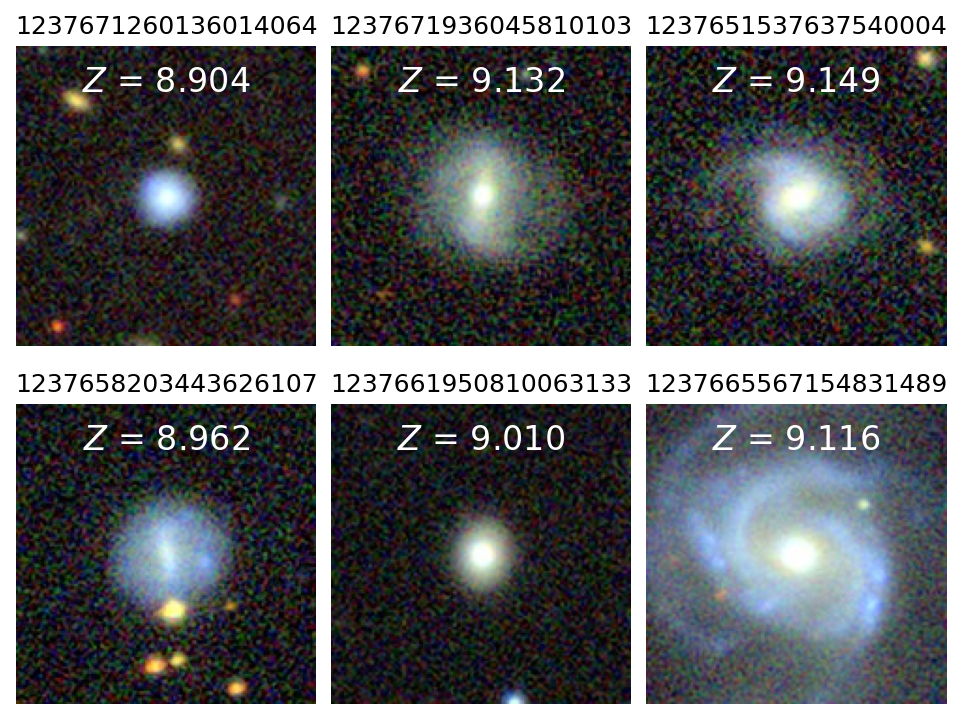

In [ ]:
# @title View six random galaxies and display their metallicities
n_galaxies = len(df)
rng = np.random.default_rng(seed=42)

fig, axes = plt.subplots(2, 3, figsize=(8, 6), dpi=150)
for i, ax in zip(rng.choice(range(n_galaxies), size=6, replace=False), axes.flat):

    objID = df.objID.iloc[i]
    im = Image.open(f'images/{objID}.jpg')
    ax.imshow(im)
    ax.set_title(objID)
    ax.axis('off')

    Z_gas = df.oh_p50.iloc[i]
    ax.text(0.5, 0.85, f'$Z$ = {Z_gas:.3f}', ha='center', transform=ax.transAxes, size=16, color='white')

fig.subplots_adjust(wspace=0.05, hspace=0.07)

### Inductive bias: symmetries in the data

At this point in the dataset creation, we can already leverage an inductive bias!  Because the universe is isotropic, we don't believe that galaxies should be seen at any specific position angles; and certainly for our task -- predicting metallicity -- we don't expect the orientation of a galaxy to matter.

The galaxy metallicity is *invariant* to image rotations and reflections. This warrants some additional thoughts:
* *Can we make arbitrary rotations?* Not really. Recall that the pixelation of the image breaks certain symmetries; pixels are square shapes, so we can only rotate by 0, 90, 180, and 270 degrees if we want to preserve the exact symmetry.
* *Which reflections should we select?* Given that we're working with a square, we should incorporate reflections across the vertical, horizontal, and two diagonal axes.
* *What about translations?* If the image spans a much larger field than the galaxy itself, such that spatially translating the galaxy doesn't result in cropping out some portions, then this symmetry approximately holds. However, we will some of the translation-invariance benefits later by using a CNN!
* *Okay, so what?* We can **augment** our dataset by generating new examples based on this symmetry group! This effectively gives us $8\times$ as much data, which will help our CNN learn more robust representations.
* Formally, we can say that predicting galaxy metallicity is invariant under the [$\mathrm{D_8}$ group action](https://en.wikipedia.org/wiki/Dihedral_group_of_order_8): 90 degree rotations and reflections (flips).


### Galaxy Dataset

Armed with this knowledge, we can define our Pytorch `GalaxyDataset`.

We allow the dataset to perform augmentations *on-the-fly*; a `transform` is called whenever a galaxy is selected. But even if we don't apply random data augmentations, specifying transforms like `transforms.ToTensor()` or `transforms.Normalize()` is necessary for formatting and normalizing our data.

In [ ]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):

        # store attributes
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

        self.image_ids = self.df['objID'].values
        self.targets = self.df['oh_p50'].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # how to index into the dataset and fetch (image, label), where
        #  - the image has shape (3, 160, 160)
        #  - the label is a floating point number
        img_name = os.path.join(self.image_dir, f"{self.image_ids[idx]}.jpg")
        image = Image.open(img_name).convert('RGB')
        label = torch.tensor(self.targets[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# @title Define $\mathrm D_8$ group with uniform sampling using `torchvision`
def pil_d8_random(img):
    choice = rng.integers(0, 7)
    if choice == 0:
        return img                              # identity
    elif choice == 1:
        return transforms.functional.rotate(img, 90, expand=True)
    elif choice == 2:
        return transforms.functional.rotate(img, 180, expand=True)
    elif choice == 3:
        return transforms.functional.rotate(img, 270, expand=True)
    elif choice == 4:
        return transforms.functional.hflip(img) # horizontal reflection
    elif choice == 5:
        return transforms.functional.vflip(img) # vertical reflection
    elif choice == 6:
        return img.transpose(Image.TRANSPOSE)   # main diagonal
    elif choice == 7:
        return img.transpose(Image.TRANSVERSE)  # anti-diagonal

# Wrap in a torchvision transform
class RandomD8PIL(transforms.RandomApply):
    def __init__(self, p=1.0):
        super().__init__([transforms.Lambda(pil_d8_random)], p=p)



### Separating the training and validation data

At this point, we're ready to split the training and validation dataset to ensure that our CNN evaluations are being done on independent galaxy samples.

During **training**, we want to inject randomness in for data augmentation (and to improve training dynamics, e.g., in minibatch/stochastic gradient descent). However, during **validation**, we typically do *not* want randomness -- no augmentation, shuffling the data set, etc.

In [ ]:
# @title Specify our transforms `train_transforms` and `val_transforms`

# make dummy dataset + dataloader
ds = GalaxyDataset(df, image_dir="images", transform=transforms.ToTensor())
dl = DataLoader(ds, batch_size=256, shuffle=True, num_workers=2)

# grab a batch of data in order to get image statistics for normalization
xb, yb = next(iter(dl))
img_mean = xb.mean((0,2,3))
img_std = xb.std((0,2,3))


# define training and validation transforms
train_transforms = transforms.Compose([
    RandomD8PIL(),
    transforms.ToTensor(),
    transforms.Normalize(mean=img_mean, std=img_std)
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=img_mean, std=img_std)
])

Finally, we can generate our training/validation datasets and dataloaders!

In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = GalaxyDataset(train_df, 'images', transform=train_transforms)
val_dataset = GalaxyDataset(val_df, 'images', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)

In [ ]:
print(f"Training batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

Training batches: 176, Validation batches: 22


## 3. The CNN architecture

Recall from our inductive biases lecture last week that *convolution layers* learn *local* signals, and a full CNN learns compositions and interactions of these local signals at a hierarchy of spatial scales.

In other words, the neural network looks something like this:

$$ {\rm CNN}(x) = {\rm Layer_{\rm final}} \Big [ \cdots \Big ( {\rm Layer_2} \big ( {\rm Layer}_1(x) \big ) \Big) \Big ], $$

where each layer could be a convolution layer, a non-linearity, a pooling layer, a linear (fully connected) layer, etc.

![Credit: https://www.analyticsvidhya.com/blog/2020/10/what-is-the-convolutional-neural-network-architecture/](https://editor.analyticsvidhya.com/uploads/90650dnn2.jpeg)



Here's a brief summary of some details:
* **Convolution:** A convolution layer slides a small filter (e.g., $3 \times 3$) across the image. You should think of it as performing cross-correlation, or in astronomy, a **matched filter** operation. However, this filter is empirically learned! It searches for specific signals (like a spiral arm or an HII region).
* **Channels:** Whereas the initial image has three color filters or *channels*, the multi-channel outputs of a convolution layer will be multiple *feature maps* of the matched-filtered inputs (passed through a non-linear function).
* **Hierarchical Features:**
    * *Early layers* find simple gradients (edges) or wavelets (Gabor filters).
    * *Middle layers* combine edges into shapes (rings, bars).
    * *Deep layers* combine shapes into physical concepts (morphology).
* **Pooling:** At the end of the network, we *pool* (average) the feature maps spatially. This is like placing an aperture over each filtered view of the galaxy and integrating the signal, aggregating spatial data into a vector that describes how much each feature is present across the entire galaxy.
* **Batch normalization** (batchnorm) is a mechanism that keeps the distribution of activations close to a Gaussian distribution. It does this by subtracting a mean and dividing by the standard deviation of inputs, modeled by two additional learnable parameters per layer. The batchnorm operation is usually inserted before the activation function layer.

*If you want to get some more intuition for what's going on in the convolution layer forward pass, then I highly recommend playing around with this [CNN spreadsheet demo](https://docs.google.com/spreadsheets/d/1cvCyXr2fb3YOGtYqr78OnaFvqX3iKSSmI4u1JZcI9k8/edit?usp=sharing).*

In [ ]:
class GalaxyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # the first convolutional layer, followed by batch normalization,
        # and then the ReLU activation function
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # (B,3,160,160) -> (B,32,80,80)
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # second convolutional layer has a similar sequence
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), #  -> (B,64,40,40)
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # the final fully connected layer is a bit different
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(5),  # creates a 64x5x5 mean pooling layer
            nn.Flatten(),             # unravels the outputs
            nn.Linear(64*5*5, 1)      # just a matrix multiplication
        )

    # this is called whenever we call the model directly
    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.fc(out)
        return out

In [ ]:

model = GalaxyCNN().to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 21,185


In [ ]:
# @title Better weight initialization
def initialize_better(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.1)

    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.1)

    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1.0)
        nn.init.constant_(m.bias, 0.0)

model.apply(initialize_better);

## Optimization and Hyperparameters

To optimize the CNN, we rely on Pytorch's automatic differentiation engine (autograd) behind the scenes. To

### Learning rate

The learning rate is the most important hyperparameter for *efficiently* training a neural network. It determines how large each update is -- you can think of it as the coefficient to the gradient that is computed from the loss function. For example, a 1-dimension loss landscape $J(\theta)$ is shown below, while gradients multiplied by the learning rate are shown as red arrows:

![](https://www.jeremyjordan.me/content/images/2018/02/Screen-Shot-2018-02-24-at-11.47.09-AM.png)

We want to make sure that we select an optimal learning rate! There's a nice empirical method for doing this described by [Leslie Smith](https://arxiv.org/pdf/1506.01186.pdf).

### Weight decay

Regularization techniques mitigate overfitting by preventing the model from becoming overly dependent on just a few neurons in the network. Weight decay is a form of regularization related to (and sometimes misconstrued as) L2 regularization -- a method for penalizing extremely large neural network weights:

$$ J(\theta) = {\rm MSE} + \frac{1}{2} \lambda ||\theta||^2,$$

where $\lambda$ is the weight decay coefficient and $\theta$ are the values of the network's weights.

Note that weight decay can sometimes clash with adaptive gradient descent methods (e.g., Adam, which is described below) and with batch normalization (introduced above). The respective solutions are to use [weight decay-decoupled Adam (AdamW)](https://arxiv.org/abs/1711.05101) and [to not use weight decay in any layer preceding batch normalization](https://blog.janestreet.com/l2-regularization-and-batch-norm/) (i.e., convolutional layers).

### Gradient descent with Momentum and adaptive momentum (Adam)

Stochastic gradient descent (SGD) is a nice straightforward method for maneuvering about the loss landscape and updating the neural network. A **momentum** term is commonly added: it simply keeps track of previous update directions, and includes a small contribution from those prior steps in the update rule:

$$ \mu_{i+1} = \beta \mu_i + \nabla J(\theta_i) $$
$$ \theta_{i+1} = \theta_i - \alpha \mu_{i+1}$$

If you take a look at many time steps, you'll find that the updates look like:

$$ \theta_{i+1} = \theta_{i} - \alpha \Big [ \nabla J(\theta_{i})  + \beta \nabla J(\theta_{i-1}) + \beta^2 \nabla J(\theta_{i-2}) + \beta^3 \nabla J(\theta_{i-3}) + \cdots \Big ]. $$

The second term looks like the Taylor expansion of an exponential function, and that's what it is sometimes referred to as an *exponentially-weighted moving average* (EMA) of the gradient. If you set the hyperparameter $\beta$ to zero, we simply go back to gradient descent. A common choice for momentum is around $\beta = 0.99$.

A good way to gain intuition for how momentum works is by playing with [this awesome demo from distill.pub](https://distill.pub/2017/momentum/). The dynamics of adding momentum to gradient descent are like that of a ball rolling down a hill -- or loss landscape.

**Adam** makes it so that the dynamics are like that of a ball *with friction* rolling down a hill. It can also be described as a simply modification of gradient descent, e.g., [here](https://ruder.io/optimizing-gradient-descent/index.html#adam).


In [ ]:
learning_rate = 1e-2
weight_decay = 1e-4
epochs = 10

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    steps_per_epoch=len(train_loader),
    epochs=epochs
)


In [ ]:
def train_one_epoch(train_loader, model, epoch_index):
    model.train()
    running_loss = 0.0


    batch_iterator = tqdm(train_loader, desc=f"Training Epoch {epoch_index+1}", leave=False)
    for x, y in batch_iterator:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()  # Reset gradients
        p = model(x)           # Forward pass
        p = p.squeeze()        # remove extra dimension
        loss = criterion(p, y) # Calculate loss
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights
        scheduler.step()       # Update learning rate

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    return avg_loss

def validate(val_loader, model):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        batch_iterator = tqdm(val_loader, desc="Validating", leave=False)
        for x, y in batch_iterator:
            x, y = x.to(device), y.to(device)
            p = model(x).squeeze()
            loss = criterion(p, y)
            running_loss += loss.item()

            all_preds.extend(p.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    return running_loss / len(val_loader), np.array(all_preds), np.array(all_targets)


In [ ]:
print("Starting training...")
train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_one_epoch(train_loader, model, epoch)
    val_loss, _, _ = validate(val_loader, model)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Starting training...


Training Epoch 1:   0%|          | 0/176 [00:00<?, ?it/s]

Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 3.9979 | Val Loss: 0.0554


Training Epoch 2:   0%|          | 0/176 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.0159 | Val Loss: 0.0145


Training Epoch 10:   0%|          | 0/176 [00:00<?, ?it/s]

Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0143 | Val Loss: 0.0118


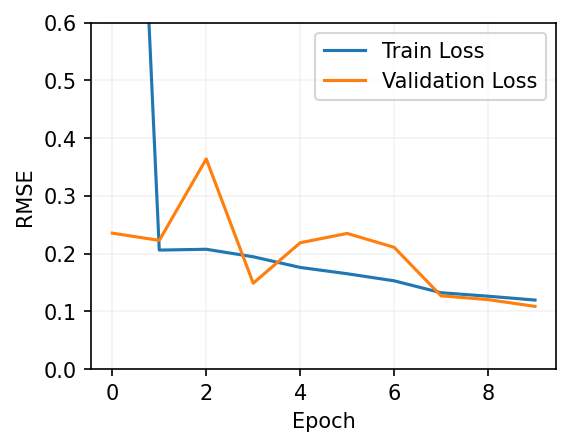

In [ ]:
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.ylim(0., 0.6)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

## Evaluate results

The best way to check results is by plotting true versus predicted metallicity values -- this tells us far more than any summary statistics.


Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Final RMSE: 0.1086 dex


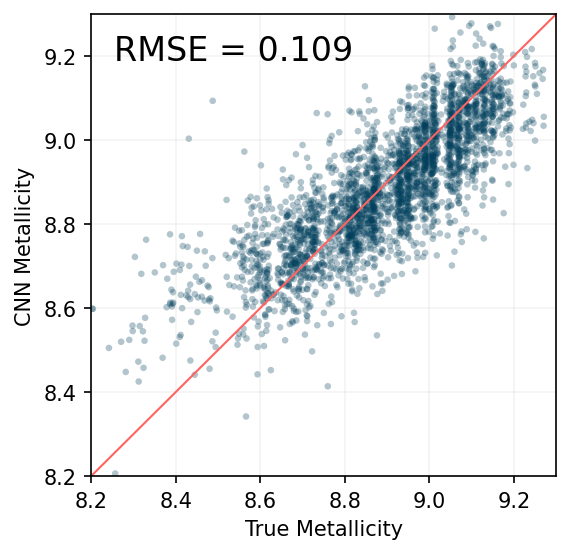

In [ ]:
# @title Get final predictions
_, preds, targets = validate(val_loader, model)

# Calculate RMSE
rmse = np.sqrt(np.mean((preds - targets)**2))
print(f"Final RMSE: {rmse:.4f} dex")

# Pred vs True plot
plt.figure(figsize=(4,4), dpi=150)
plt.scatter(targets, preds, alpha=0.3, s=10, c='#003f5c', edgecolors='none')
plt.plot([8.0, 9.4], [8.0, 9.4], c='#ff6361', lw=1) # Identity line
plt.xlabel('True Metallicity')
plt.ylabel('CNN Metallicity')
plt.text(0.05, 0.9, f'RMSE = {rmse:.3f}', transform=plt.gca().transAxes, fontsize=16)
plt.grid(True, alpha=0.15)
plt.xlim(8.2, 9.3)
plt.ylim(8.2, 9.3)
plt.show()

## Bonus: CNNs with a modern architecture and fine-tuned from pretrained weights


In [ ]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# load pretrained weights
weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

# repurpose final layer ("classifier") as a regressor
model.classifier = nn.Linear(1280, 1, bias=True)

model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 20,178,769


In [ ]:
learning_rate = 3e-4
weight_decay = 0
epochs = 3

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    steps_per_epoch=len(train_loader),
    epochs=epochs
)


In [ ]:

print("Training much bigger model...")
train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_one_epoch(train_loader, model, epoch)
    val_loss, _, _ = validate(val_loader, model)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Training much bigger model...


Training Epoch 1:   0%|          | 0/176 [00:00<?, ?it/s]

Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 21.5832 | Val Loss: 0.0441


Training Epoch 2:   0%|          | 0/176 [00:00<?, ?it/s]

Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.0319 | Val Loss: 0.0277


Training Epoch 3:   0%|          | 0/176 [00:00<?, ?it/s]

Validating:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.0196 | Val Loss: 0.0137


Validating:   0%|          | 0/22 [00:00<?, ?it/s]

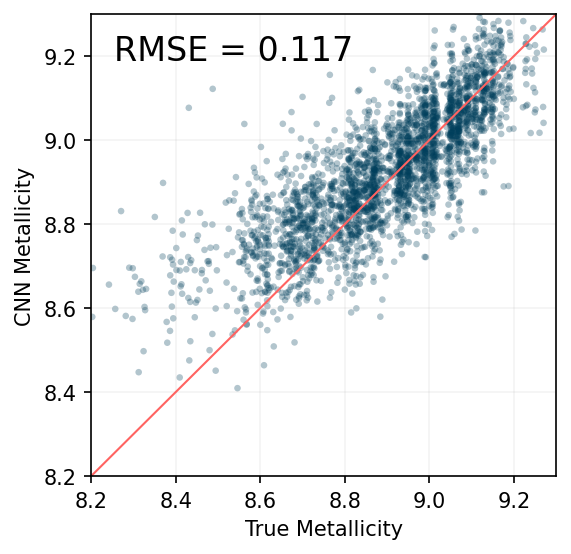

In [ ]:
# @title Again show Predicted vs True plot
_, preds, targets = validate(val_loader, model)
rmse = np.sqrt(np.mean((preds - targets)**2))

# Pred vs True plot
plt.figure(figsize=(4,4), dpi=150)
plt.scatter(targets, preds, alpha=0.3, s=10, c='#003f5c', edgecolors='none')
plt.plot([8.0, 9.4], [8.0, 9.4], c='#ff6361', lw=1) # Identity line
plt.xlabel('True Metallicity')
plt.ylabel('CNN Metallicity')
plt.text(0.05, 0.9, f'RMSE = {rmse:.3f}', transform=plt.gca().transAxes, fontsize=16)
plt.grid(True, alpha=0.15)
plt.xlim(8.2, 9.3)
plt.ylim(8.2, 9.3)
plt.show()